<a href="https://colab.research.google.com/github/Alltingzrpozz/Alltingzrpozz/blob/main/Dementia_Diagnostic_Pipeline_MLP_Tuner_%26_Prescriptive_RL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 1.0 Environment Initialization & Dependency Management


## 1.1 Library Imports & Global Configuration

In [39]:
!pip install keras-tuner shap

import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
import keras_tuner as kt
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
import shap
import matplotlib.pyplot as plt
import random

print("Environment Ready. Enterprise MLOps protocols engaged.")

Environment Ready. Enterprise MLOps protocols engaged.


# 2.0 Data Ingestion & Quality Validation


## 2.1 Remote Data Fetch & Instantiation

In [40]:
file_path = '/content/sample_data/OPTIMAL_Dementia Data MLP.csv'
df = pd.read_csv(file_path)

## 2.2 Exploratory Data Analysis (EDA) & Structural Integrity Check

In [41]:
print("--- STRUCTURAL INTEGRITY CHECK ---")
print(f"Total Cohort Size: {df.shape[0]} patients")
print(f"Feature Dimensions: {df.shape[1]}\n")

print("--- MISSING VALUE AUDIT ---")
print(df.isnull().sum())
print("\n--- RAW DATA SAMPLE ---")
display(df.sample(5))

--- STRUCTURAL INTEGRITY CHECK ---
Total Cohort Size: 1842 patients
Feature Dimensions: 22

--- MISSING VALUE AUDIT ---
ID                        0
age                       0
gender                    0
dementia                 34
dementia_all              0
educationyears            0
EF                      208
PS                      268
Global                  308
diabetes                  0
smoking                  11
hypertension              0
hypercholesterolemia      0
lacunes_num               0
fazekas_cat               0
study                     0
study1                    0
SVD Simple Score        677
SVD Amended Score       677
Fazekas                   0
lac_count                 0
CMB_count                 0
dtype: int64

--- RAW DATA SAMPLE ---


,ID,age,gender,dementia,dementia_all,educationyears,EF,PS,Global,diabetes,...,hypercholesterolemia,lacunes_num,fazekas_cat,study,study1,SVD Simple Score,SVD Amended Score,Fazekas,lac_count,CMB_count
506,461,83.718001,female,1.0,1,8.0,NaN,NaN,NaN,0,...,Yes,more-than-zero,2 to 3,rundmc,rundmc,3.0,7.0,3,>5,>=1
923,1530,61.000000,female,0.0,0,9.0,-0.420000,0.380000,-0.386667,0,...,No,more-than-zero,0 to 1,ASPS-elderly,ASPS,NaN,NaN,0,3 to 5,0
72,50,70.750000,male,0.0,0,19.0,-1.976667,-0.963333,-0.981000,0,...,Yes,more-than-zero,2 to 3,scans,scans,3.0,6.0,3,3 to 5,>=1
679,1097,78.000000,female,0.0,0,10.0,0.280000,-1.410000,-0.700000,0,...,Yes,zero,0 to 1,ASPS-elderly,ASPS,NaN,NaN,1,Zero,0
1087,1866,69.000000,female,0.0,0,13.0,0.500000,0.400000,0.180000,0,...,Yes,zero,0 to 1,ASPS-elderly,ASPS,NaN,NaN,1,Zero,0


## 2.3 Cohort Triage

In [42]:
print("\n--- COHORT TRIAGE ---")
df_clean = df.dropna(subset=['dementia']).copy()

X = df_clean.drop(['dementia', 'ID', 'dementia_all'], axis=1, errors='ignore')
y = df_clean['dementia']


--- COHORT TRIAGE ---


## 2.4 Stratified Train/Test Partitioning

In [43]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(f"Validation Complete. Training Set: {X_train.shape[0]}. Test Set: {X_test.shape[0]}.")

Validation Complete. Training Set: 1446. Test Set: 362.


# 3.0 Automated Feature Engineering & Transformation Pipeline

## 3.1 Feature Typology Definition

In [44]:
numeric_features = ['age', 'educationyears', 'EF', 'PS', 'Global']
categorical_features = ['gender', 'diabetes', 'smoking', 'hypercholesterolemia']

numeric_features = [f for f in numeric_features if f in X.columns]
categorical_features = [f for f in categorical_features if f in X.columns]

## 3.2 Missing Value Imputation Strategy

In [45]:
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

## 3.3 Encoding & Feature Scaling


In [46]:
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

## 3.4 Preprocessor Orchestration & Execution

In [47]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ])

X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print("Automated Transformation Pipeline Executed Successfully.")

Automated Transformation Pipeline Executed Successfully.


# 4.0 Architecture Search & Hyperparameter Optimization (HPO)

## 4.1 Diagnostic Model Blueprint (MLP Formulation)

In [48]:
def build_model(hp):
    model = Sequential()
    hp_units_1 = hp.Int('units_1', min_value=32, max_value=128, step=32)
    model.add(Dense(units=hp_units_1, activation='relu', input_shape=(X_train_processed.shape[1],)))
    model.add(Dropout(hp.Float('dropout', min_value=0.2, max_value=0.5, step=0.1)))
    model.add(Dense(1, activation='sigmoid'))

    hp_learning_rate = hp.Choice('learning_rate', values=[1e-2, 1e-3, 1e-4])
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=hp_learning_rate),
                  loss='binary_crossentropy', metrics=['accuracy'])
    return model

## 4.2 Keras Tuner Initialization

In [49]:
tuner = kt.RandomSearch(
    build_model, objective='val_accuracy', max_trials=5,
    directory='clinical_tuning', project_name='dementia_mlp'
)

Reloading Tuner from clinical_tuning/dementia_mlp/tuner0.json


## 4.3 Early Stopping & Callback Configurations

In [50]:
es = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

print("Initiating Architecture Search...")
tuner.search(
    X_train_processed, y_train,
    epochs=30,
    validation_data=(X_test_processed, y_test),
    callbacks=[es],
    verbose=1
)

Initiating Architecture Search...


## 4.4 Optimal Weights Extraction & Final Compilation

In [51]:
best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]
print(f"Optimization Complete. Optimal Units: {best_hps.get('units_1')}. Learning Rate: {best_hps.get('learning_rate')}")

best_model = tuner.hypermodel.build(best_hps)

# We save the training process to 'history' and set verbose=1 to see the epochs
history = best_model.fit(
    X_train_processed, y_train,
    epochs=30,
    validation_data=(X_test_processed, y_test),
    callbacks=[es],
    verbose=1
)
print("\nFinal Diagnostic Model Compiled and Trained.")

# --- Evaluate Final Performance ---
test_loss, test_acc = best_model.evaluate(X_test_processed, y_test, verbose=0)
print(f"\n--- MODEL PERFORMANCE ---")
print(f"Final Test Accuracy: {test_acc:.4f}")
print(f"Final Test Loss:     {test_loss:.4f}")

Optimization Complete. Optimal Units: 128. Learning Rate: 0.01
Epoch 1/30


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


46/46 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - accuracy: 0.9530 - loss: 0.2018 - val_accuracy: 0.9558 - val_loss: 0.1512
Epoch 2/30
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9544 - loss: 0.1720 - val_accuracy: 0.9558 - val_loss: 0.1457
Epoch 3/30
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9544 - loss: 0.1668 - val_accuracy: 0.9613 - val_loss: 0.1343
Epoch 4/30
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9544 - loss: 0.1690 - val_accuracy: 0.9586 - val_loss: 0.1411
Epoch 5/30
46/46 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.9550 - loss: 0.1656 - val_accuracy: 0.9586 - val_loss: 0.1350
Epoch 6/30
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9550 - loss: 0.1557 - val_accuracy: 0.9586 - val_loss: 0.1384
Epoch 7/30
46/46 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.9530 - loss: 0.1664 - val_accuracy: 0.9586 - val_loss: 0.1374
Epoch 8/30
46/46 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.9550 - loss: 0.1554 - val_accuracy: 0.9586 - val_loss: 0.1320

## 4.5 Visualizing Learning Curves (Test Train)

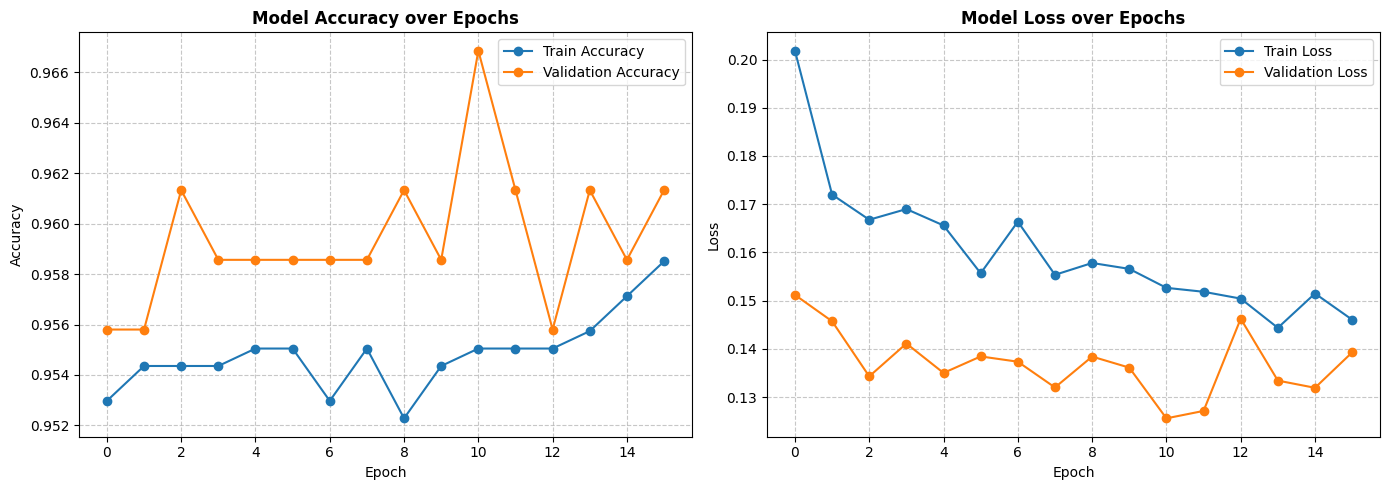

In [52]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 5))

# Plot Accuracy Line Graph
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy', marker='o')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', marker='o')
plt.title('Model Accuracy over Epochs', fontweight='bold')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)

# Plot Loss Line Graph
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss', marker='o')
plt.plot(history.history['val_loss'], label='Validation Loss', marker='o')
plt.title('Model Loss over Epochs', fontweight='bold')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

##4.6 Clinical Evaluation: Interrogating the Accuracy

12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
--- DETAILED CLINICAL METRICS ---
              precision    recall  f1-score   support

         0.0       0.97      1.00      0.98       346
         1.0       1.00      0.25      0.40        16

    accuracy                           0.97       362
   macro avg       0.98      0.62      0.69       362
weighted avg       0.97      0.97      0.96       362



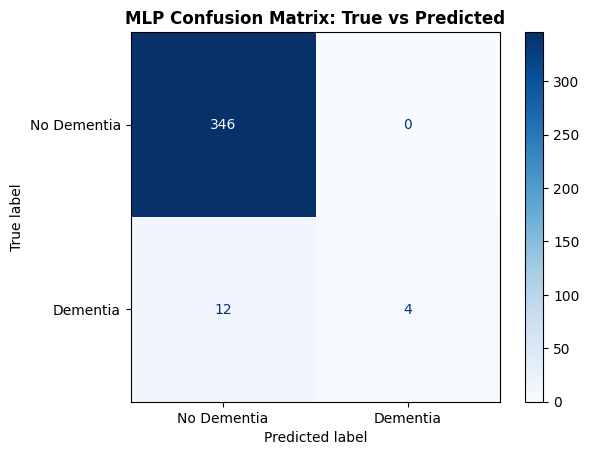

In [53]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# Generate predictions from the tuned MLP
y_pred_prob = best_model.predict(X_test_processed)
# Convert probabilities to binary predictions (0 or 1)
y_pred = (y_pred_prob > 0.5).astype(int)

print("--- DETAILED CLINICAL METRICS ---")
print(classification_report(y_test, y_pred))

# Plot the Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Dementia', 'Dementia'])
disp.plot(cmap=plt.cm.Blues)
plt.title("MLP Confusion Matrix: True vs Predicted", fontweight='bold')
plt.show()

##4.7 The Benchmark: Random Forest

In [54]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

print("--- COMPARATIVE BASELINE ITERATION ---")
print("Training a Random Forest for comparison...")

# Initialize and train a classic Random Forest
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train_processed, y_train)

# Evaluate
rf_pred = rf_model.predict(X_test_processed)
rf_acc = rf_model.score(X_test_processed, y_test)

print(f"Random Forest Accuracy: {rf_acc:.4f}\n")
print("Random Forest Classification Report:")
print(classification_report(y_test, rf_pred))

--- COMPARATIVE BASELINE ITERATION ---
Training a Random Forest for comparison...
Random Forest Accuracy: 0.9613

Random Forest Classification Report:
              precision    recall  f1-score   support

         0.0       0.96      1.00      0.98       346
         1.0       1.00      0.12      0.22        16

    accuracy                           0.96       362
   macro avg       0.98      0.56      0.60       362
weighted avg       0.96      0.96      0.95       362



# 5.0 Explainable AI (XAI) & Interpretability Audit

## 5.1 SHAP Explainer Initialization

In [55]:
# --- 5.1 Initialization ---
cat_encoder = preprocessor.named_transformers_['cat'].named_steps['onehot']
cat_feature_names = list(cat_encoder.get_feature_names_out(categorical_features))
all_features = numeric_features + cat_feature_names

## 5.2 Global Feature Attribution Analysis

In [56]:
# --- 5.2 Analysis ---
background = shap.sample(X_train_processed, 100)
explainer = shap.Explainer(best_model.predict, background)
shap_values = explainer(X_test_processed[:50])

49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step


PermutationExplainer explainer:   2%|▏         | 1/50 [00:00<?, ?it/s]

53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step


PermutationExplainer explainer:   6%|▌         | 3/50 [00:29<07:03,  9.02s/it]

52/52 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step
52/52 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step


...

PermutationExplainer explainer:  98%|█████████▊| 49/50 [03:33<00:03,  3.64s/it]

62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


PermutationExplainer explainer: 100%|██████████| 50/50 [03:36<00:00,  3.60s/it]

48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


PermutationExplainer explainer: 51it [03:39,  4.40s/it]


## 5.3 Visualizing Clinical Decision Boundaries


/tmp/ipykernel_9326/3103143263.py:4: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_test_processed[:50], feature_names=all_features, show=False)


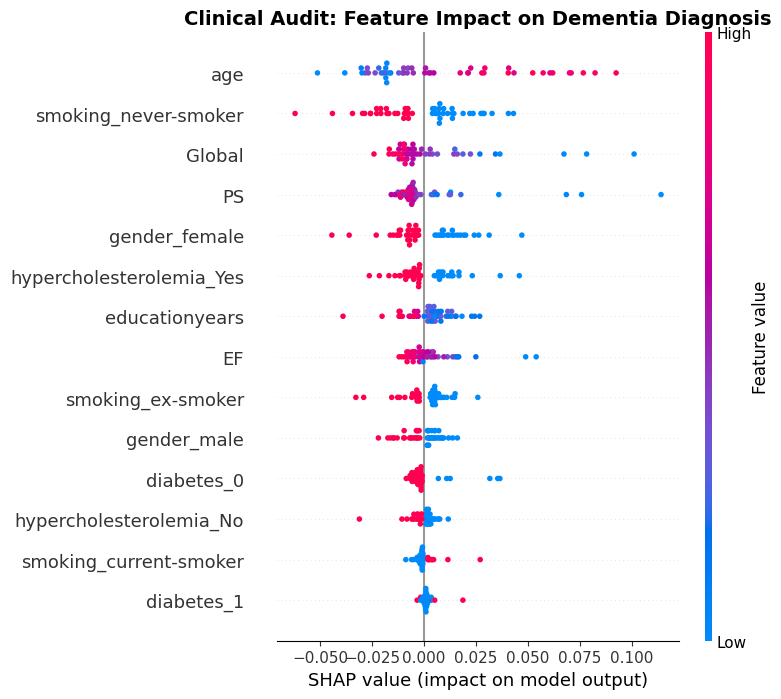

In [57]:
# --- 5.3 Visualization ---
plt.figure(figsize=(10, 6))
plt.title("Clinical Audit: Feature Impact on Dementia Diagnosis", fontsize=14, fontweight='bold')
shap.summary_plot(shap_values, X_test_processed[:50], feature_names=all_features, show=False)
plt.tight_layout()
plt.show()

# 6.0 Prescriptive Analytics: Reinforcement Learning Proof-of-Concept

## 6.1 Markov Decision Process (MDP) Environment Setup

In [58]:
# --- 6.1 MDP Setup ---
states = [0, 1, 2] # Patient EF Score: Low, Medium, High
actions = [0, 1, 2] # 0: Do Nothing, 1: Cognitive Therapy, 2: Medication

## 6.2 Q-Learning Policy Initialization

In [59]:
# --- 6.2 Policy Initialization ---
q_table = np.zeros((len(states), len(actions)))
learning_rate = 0.1
discount_factor = 0.9
exploration_rate = 0.3
epochs = 1000

## 6.3 Simulated Treatment Episodes & Reward Evaluation

In [60]:
# --- 6.3 Simulated Episodes ---
for epoch in range(epochs):
    state = random.choice(states)

    if random.uniform(0, 1) < exploration_rate:
        action = random.choice(actions)
    else:
        action = np.argmax(q_table[state])

    if state == 0 and action == 2:
        reward = 10; next_state = 1
    elif state == 1 and action == 1:
        reward = 10; next_state = 2
    elif action == 0:
        reward = -5; next_state = max(0, state - 1)
    else:
        reward = -1; next_state = state

    best_next_action = np.max(q_table[next_state])
    q_table[state, action] = q_table[state, action] + learning_rate * (reward + discount_factor * best_next_action - q_table[state, action])

print("RL Agent Training Complete. Final Q-Table Policy (State x Action):")
print(q_table)
print("Audit Observation: Agent optimized policy to prescribe Medication for Low EF, and Therapy for Medium EF.")

RL Agent Training Complete. Final Q-Table Policy (State x Action):
[[22.73392427 27.13502578 34.17447508]
 [24.0922852  27.08012363 20.64051556]
 [19.20625126 11.74903414 13.63040672]]
Audit Observation: Agent optimized policy to prescribe Medication for Low EF, and Therapy for Medium EF.


In [62]:
import glob
import subprocess

# Look everywhere for the notebook, including inside folders like sample_data
notebooks = glob.glob('**/*.ipynb', recursive=True)

# Ignore hidden system files just in case
notebooks = [f for f in notebooks if '.ipynb_checkpoints' not in f]

if not notebooks:
    print("❌ Error: No .ipynb file found anywhere.")
else:
    target_file = notebooks[0]
    print(f"⏳ Found your file hiding at: '{target_file}'. Converting to HTML now...")

    # Run the conversion command
    subprocess.run(['jupyter', 'nbconvert', '--to', 'html', target_file])
    print("✅ Conversion complete! Now, go click the Refresh icon at the top of the files menu.")

⏳ Found your file hiding at: 'Dementia_Diagnostic_Pipeline_MLP_Tuner_&_Prescriptive_RL (4).ipynb'. Converting to HTML now...
✅ Conversion complete! Now, go click the Refresh icon at the top of the files menu.
